# Glacial Lake Dynamics in the Baba Mountains (Koh e Baba), Central Afghanistan. 

## Introductions 
### 1. Study Area
The baba mountain range (koh e Baba) is located in central Afghanistan (Bamyan Province). The mountain contains numerous small glacial lakes that are highly sensitive to climate fluctuations. 

### 2. Data Extraction Methodology 
Given the relatively surface area of glacier and glacier lakes in this region, the 10m sentinel -2 Level-2A with zero cloud cover and minimal seasional snow cover was selected for this study. The selected imagery underwent segmantation followed by supervised classification using Random Forest classifier. After some manual editing using visual image interpretation techniques, and cleaning the data, all the attribute tables were calculated in ArcGIS pro environment. To facilitate modern goespatail analysis in python, the shapefile were exported to GeoJason format

### 3. Goals 

The primary assissment of this project is to perform decadle (2016-2025) change assessment to identify:
1. Change in total surface Area
2. The number of newly formad glacial lakes.
3. Trends in lake size distribution

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
#loading the data
Lakes_16=gpd.read_file('../Data/gl2016.geojson')
lakes_25=gpd.read_file('../Data/gl2025.geojson')

print('Data loaded successfully!')

Data loaded successfully!


In [2]:
# I want to explore and display some of the basic information about the datasets, such as the number of records,
# column names, and a preview of the data.This will help me understand the structure of the datasets 
# and identify any potential issues or insights that can be derived from them.

print('gl2016 Dataset Info')
print(Lakes_16.info())
print(Lakes_16.head())
columns_to_hide = ['geometry', 'Shape_Leng', 'Shape_Area','Shape_Length']
display(Lakes_16.drop(columns=columns_to_hide).head(35))    
print('2025 Dataset Info')
print(lakes_25.info())
print(lakes_25.head()) 
columns_to_hide = ['geometry', 'Shape_Length', 'Shape_Area']
display(lakes_25.drop(columns=columns_to_hide).head(40))



gl2016 Dataset Info
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   OBJECTID      35 non-null     int32   
 1   gridcode      34 non-null     float64 
 2   ClassName     35 non-null     object  
 3   Longitude     35 non-null     float64 
 4   Latitude      35 non-null     float64 
 5   GLIMS_ID      35 non-null     object  
 6   ClassValue    34 non-null     float64 
 7   Shape_Leng    34 non-null     float64 
 8   AreasqKM      35 non-null     float64 
 9   Altitude      35 non-null     int32   
 10  Shape_Length  35 non-null     float64 
 11  Shape_Area    35 non-null     float64 
 12  geometry      35 non-null     geometry
dtypes: float64(8), geometry(1), int32(2), object(2)
memory usage: 3.4+ KB
None
   OBJECTID  gridcode     ClassName  Longitude  Latitude         GLIMS_ID  \
0         1       2.0  Glacier_Lake     67.678    34

,OBJECTID,gridcode,ClassName,Longitude,Latitude,GLIMS_ID,ClassValue,AreasqKM,Altitude
0,1,2.0,Glacier_Lake,67.678,34.665,GL067678E34665N,2.0,0.025581,4057
1,2,2.0,Glacier_Lake,67.715,34.661,GL067715E34661N,2.0,0.018082,4145
2,3,1.0,Glacier_Lake,67.681,34.659,GL067681E34659N,2.0,0.025596,4143
3,4,4.0,Glacier_Lake,67.714,34.658,GL067714E34658N,2.0,0.015781,4220
4,5,74.0,Glacier_Lake,67.764,34.657,GL067764E34657N,2.0,0.007098,4227
5,6,2.0,Glacier_Lake,67.755,34.652,GL067755E34652N,2.0,0.012532,4304
6,7,2.0,Glacier_Lake,67.671,34.650,GL067671E34650N,2.0,0.018503,4228
7,8,1.0,Glacier_Lake,67.659,34.649,GL067659E34649N,2.0,0.052630,4337
8,9,48.0,Glacier_Lake,67.777,34.648,GL067777E34648N,2.0,0.013988,4351
9,10,1.0,Glacier_Lake,67.681,34.646,GL067681E34646N,2.0,0.066354,4626


2025 Dataset Info
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   OBJECTID      40 non-null     int32   
 1   Id            32 non-null     float64 
 2   gridcode      32 non-null     float64 
 3   ClassName     40 non-null     object  
 4   Longitude     40 non-null     float64 
 5   Latitude      40 non-null     float64 
 6   GLIMS_ID      40 non-null     object  
 7   ClassValue    40 non-null     int32   
 8   AreasqKM      40 non-null     float64 
 9   Altitude      40 non-null     int32   
 10  Shape_Length  40 non-null     float64 
 11  Shape_Area    40 non-null     float64 
 12  geometry      40 non-null     geometry
dtypes: float64(7), geometry(1), int32(3), object(2)
memory usage: 3.7+ KB
None
   OBJECTID       Id  gridcode     ClassName  Longitude  Latitude  \
0         1   9020.0       3.0  Glacier_Lake     67.635    34.

,OBJECTID,Id,gridcode,ClassName,Longitude,Latitude,GLIMS_ID,ClassValue,AreasqKM,Altitude
0,1,9020.0,3.0,Glacier_Lake,67.635,34.664,GL067635E34664N,2,0.017925,4190
1,2,10525.0,2.0,Glacier_Lake,67.714,34.658,GL067714E34658N,2,0.013973,4220
2,3,12416.0,2.0,Glacier_Lake,67.755,34.652,GL067755E34652N,2,0.012485,4304
3,4,13581.0,40.0,Glacier_Lake,67.777,34.647,GL067777E34647N,2,0.037547,4365
4,5,15263.0,53.0,Glacier_Lake,67.619,34.640,GL067619E34640N,2,0.003423,4642
5,6,19302.0,4.0,Glacier_Lake,67.951,34.629,GL067951E34629N,2,0.021431,4398
6,7,20268.0,9.0,Glacier_Lake,67.952,34.626,GL067952E34626N,2,0.012372,4483
7,8,24573.0,4.0,Glacier_Lake,67.968,34.604,GL067968E34604N,2,0.018739,4590
8,9,28419.0,165.0,Glacier_Lake,67.992,34.583,GL067992E34583N,2,0.008078,4483
9,10,29599.0,140.0,Glacier_Lake,68.033,34.574,GL068033E34574N,2,0.032936,4298


As the displayed info showes that there are few Nulls in gl2025 and couple null in gl2016 dataset. 
Since the columns that have Nulls are not part of the analysis, I want to continue with this datasets. 
Columns such as, Lat, Lon, GLIMS_ID, Area, Mean Elevation is going to be used in this analysis

In [3]:
# Checking the CRS for both datasets
print('CRS of gl2016 dataset:', Lakes_16.crs)
print('CRS of gl2025 dataset:', lakes_25.crs)   

CRS of gl2016 dataset: EPSG:4326
CRS of gl2025 dataset: EPSG:4326


In [4]:
#change the crs of both datasets to a projected coordinate system (UTM Zone 42N, EPSG:32642)
Lakes_16 = Lakes_16.to_crs(epsg=32642)
lakes_25 = lakes_25.to_crs(epsg=32642) 
print('CRS of gl2016 dataset after transformation:', Lakes_16.crs)
print('CRS of gl2025 dataset after transformation:', lakes_25.crs)

CRS of gl2016 dataset after transformation: EPSG:32642
CRS of gl2025 dataset after transformation: EPSG:32642


In [5]:

# Calculate area in Square Kilometers (Area is in m2, so divide by 1,000,000)
Lakes_16['Area_km2'] = Lakes_16.geometry.area / 10**6
lakes_25['Area_km2'] = lakes_25.geometry.area / 10**6

print(f"2016 Total Area: {Lakes_16['Area_km2'].sum():.3f} km²")
print(f"2025 Total Area: {lakes_25['Area_km2'].sum():.3f} km²")

#calculate the net increase/decrease in the total area of lakes
area_change = lakes_25['Area_km2'].sum() - Lakes_16['Area_km2'].sum()
print(f"Net area change from 2016 to 2025: {area_change:.3f} km²")

2016 Total Area: 0.570 km²
2025 Total Area: 0.623 km²
Net area change from 2016 to 2025: 0.053 km²


In [6]:
# Getting the count of lakes for both years
count_16 = len(Lakes_16)
count_25 = len(lakes_25)

print(f"Number of lakes in 2016: {count_16}")
print(f"Number of lakes in 2025: {count_25}")

# Calculate the net increase/decrease in the number of lakes

print(f"Net increase: {count_25 - count_16} new lakes detected.")

Number of lakes in 2016: 35
Number of lakes in 2025: 40
Net increase: 5 new lakes detected.


The results shows that lakes increased in 2025 by 0.053 km2 and 5 new lakes emerged

### Visualizing the area and count increase in charts

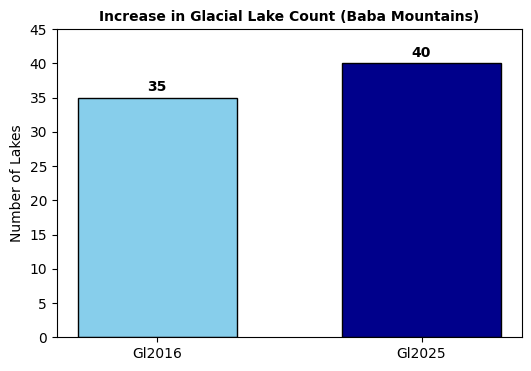

In [7]:
import matplotlib.pyplot as plt

# Data for plotting
years = ['Gl2016', 'Gl2025']
counts = [count_16, count_25]

plt.figure(figsize=(6, 4))
plt.bar(years, counts, color=['skyblue', 'darkblue'], edgecolor='black', width=0.6)

# Adding labels and title
plt.title('Increase in Glacial Lake Count (Baba Mountains)', fontsize=10, fontweight='bold')
plt.ylabel('Number of Lakes')
plt.ylim(0, 45) # Setting limit slightly higher than max count for clarity

# Adding the count labels on top of bars
for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.show()

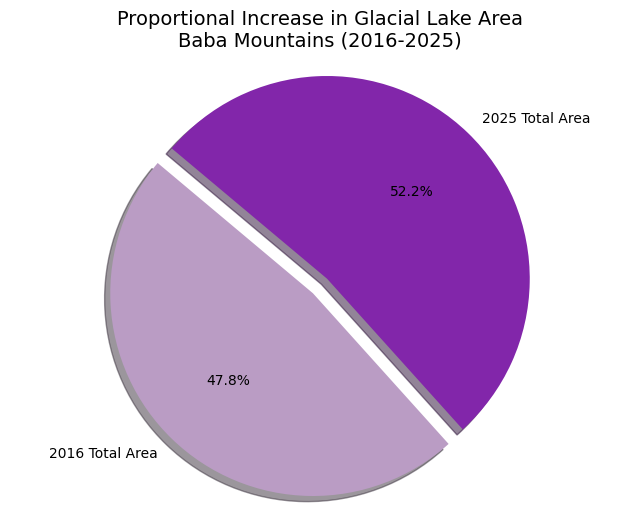

In [8]:
import matplotlib.pyplot as plt

# Data from your UTM 42N calculations
labels = ['2016 Total Area', '2025 Total Area']
areas = [0.570, 0.623]
colors = ["#ba9cc4", "#8226AA"]  
explode = (0, 0.1)  # "Explode" the 2025 slice to highlight the increase

# Create the Pie Chart
plt.figure(figsize=(8, 6))
plt.pie(areas, explode=explode, labels=labels, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.title('Proportional Increase in Glacial Lake Area\nBaba Mountains (2016-2025)', fontsize=14)
plt.axis('equal')  # Ensures the pie is drawn as a circle
plt.show()

## Observations:
The number of glacial lake increased from 35 to 40 between 2016 and 2025 as well as the area shows a total increase of 9.3%

In [9]:
import pandas as pd

# Defining elevation bins and labels
# in Hindu Kush Himalaya region, the elevation of glacial lakes typically ranges from around 2200 meters to over 6200 meters.
# in Baba Mountains, the elevation of glacial lakes typically ranges from around 3000 meters to over 5000 meters.
# 3000-4000m (Low), 4000-5000m (High)
bins = [0, 4000, 5000]
labels = ['Low (Below 4000m)', 'High (Above 4000m)']

# Apply bins to both datasets
Lakes_16['Elev_Class'] = pd.cut(Lakes_16['Altitude'], bins=bins, labels=labels)
lakes_25['Elev_Class'] = pd.cut(lakes_25['Altitude'], bins=bins, labels=labels)


print("2016 Elevation Class Distribution:")
print(Lakes_16['Elev_Class'].value_counts())
print("\n2025 Elevation Class Distribution:")
print(lakes_25['Elev_Class'].value_counts())


2016 Elevation Class Distribution:
Elev_Class
High (Above 4000m)    34
Low (Below 4000m)      1
Name: count, dtype: int64

2025 Elevation Class Distribution:
Elev_Class
High (Above 4000m)    39
Low (Below 4000m)      1
Name: count, dtype: int64


### Observation:
Between 2016 and 2025, a significant spatial shift in glacial lake distribution was observed. While the total number of lakes increased from 35 to 40, this growth was exclusively concentrated above 4000m. This upward migration of lake formation indicates that the melting threshold in the Baba Mountains is ascending, consistent with regional warming trends that displace the snowline to higher elevations.

In [19]:
import geopandas as gpd
import leafmap

# 1. LOAD THE DATA (Crucial: This fixes the NameError)
# Make sure the path to your shapefile or geojson is correct
lake_25 = gpd.read_file('../Data/gl2025.geojson') 
lake_16 = gpd.read_file('../Data/gl2016.geojson')    
# 2. Add the Elevation Class (The 4000m rule we discussed)
lake_25['Class'] = lake_25['Altitude'].apply(lambda x: 'High' if x >= 4000 else 'Low')
lake_16['Class'] = lake_16['Altitude'].apply(lambda x: 'High' if x >= 4000 else 'Low')  

# 3. Create the Interactive Online Map
m = leafmap.Map(center=[34.665, 67.678], zoom=12)

# 4. Add Sentinel-2 WMS Layer (Online, no authentication needed)
m.add_wms_layer(
    url="https://services.sentinel-hub.com/ogc/wms/ed8003f5-06d2-43c3-93d3-f54e176378e0", 
    layers="TRUE-COLOR", 
    name="Sentinel-2 Sept 2025"
)

# 5. Add your polygons
# High Altitude in Red, Low in Cyan
m.add_gdf(lake_25, layer_name="Glacial Lakes", fill_colors=["Blue", "DarkBlue"])
m.add_gdf(lake_16, layer_name="Glacial Lakes 2016", fill_colors=["Blue", "lightblue"])    

m

Map(center=[34.665, 67.678], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

In [23]:
import leafmap
import geopandas as gpd

# 1. Load your data
# Using your specific variable names and paths
lake_25 = gpd.read_file('../Data/gl2025.geojson').to_crs(epsg=4326)
lake_16 = gpd.read_file('../Data/gl2016.geojson').to_crs(epsg=4326)

# 2. Initialize Map
m = leafmap.Map(center=[34.665, 67.678], zoom=12)

# 3. Add the specific Sentinel-2 capture as WMS
m.add_wms_layer(
    url="https://services.sentinel-hub.com/ogc/wms/ed8003f5-06d2-43c3-93d3-f54e176378e0", 
    layers="TRUE-COLOR", 
    name="Sentinel-2 Background"
)

# 4. Add the Layers with distinct colors
# 2016 in a lighter blue to represent the baseline
m.add_gdf(lake_16, layer_name="Glacial Lakes 2016", fill_colors=["#add8e6"]) # LightBlue

# 2025 in a darker/bolder blue to show current extent
m.add_gdf(lake_25, layer_name="Glacial Lakes 2025", fill_colors=["#00008b"]) # DarkBlue

# 5. Add the Legend
legend_dict = {
    'Glacial Lakes 2016': '#add8e6',
    'Glacial Lakes 2025': '#00008b'
}

m.add_legend(title="Baba Mountains Lake Change", legend_dict=legend_dict)

m

Map(center=[34.665, 67.678], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…